# Central spectral weight versus subsystem width
Fixed $N_x=20$, $N_y=32$, hard walls, $\alpha_1=1$: all 100 saved pure-state endpoints at cycle 64. Vary the contiguous subsystem width $A_y=1,\ldots,16$, retaining every x and both orbitals with origin $y_0=0$. Compute the integrated centered spectral density in $[-L,L]$ directly from eigenvalue counts, without histogram binning or new circuit simulation.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():
    AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(AVAILABLE_CPUS[0],AVAILABLE_CPUS[min(1,len(AVAILABLE_CPUS)-1)]) # editable inclusive range
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [0, 1]


## Estimators
The occupation correlation matrix is $G_A=F_AF_A^\dagger$ and its centered version is $Q_A=2G_A-\mathbf{1}_A$, with eigenvalues $\lambda=2\nu-1$. (Older caches call $Q_A$ the centered covariance `G`.) Rows use $i=2N_xy+2x+\mu$ and only the active columns of each saved frame are retained. Diagonalize each trajectory separately before any average.

Define $n_s(L,A_y)=\sum_j\mathbf{1}_{|\lambda_{s,j}|\le L}$ and $m_s(A_y)=\sum_j\mathbf{1}_{|\lambda_{s,j}|<1-\tau}$, where $\tau=10^{-8}$. The normalization of the previous mixed-mode density gives
$$I_L^{\rm mixed}(A_y)=\int_{-L}^{L}\rho_{\rm mixed}(\lambda;A_y)\,d\lambda=\frac{\sum_s n_s}{\sum_s m_s}.$$
This ratio of pooled counts differs from the mean of individual normalized ratios. Also retain the raw mean count $\overline n_L=\sum_s n_s/100$ and the integral normalized over all modes, $I_L^{\rm all}=\overline n_L/(40A_y)$. The normalized integrals and the raw count need not share a scaling law.

Test the proposed form $a+b\log d(A_y)$, with $d=(32/\pi)\sin(\pi A_y/32)$ and lattice spacing one. Fits are descriptive ordinary least squares. Uncertainty propagates the full covariance across widths from the 100 independent trajectories; ratio uncertainties use the delta method. Eigenvalues and widths are not independent samples. The default fit range is $4\le A_y\le16$, with sensitivity fits starting at 2 and 8. All cuts start at zero; there is no translation average or inferred reflection to widths greater than half the system.

## Configuration and input validation
Change L in the statistics cell without recomputing spectra. Input completion receipts, sizes, hashes, identities and sample IDs are verified even on cache reuse.

In [2]:
from pathlib import Path
import sys,json,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display,Image,Markdown
OUT=Path.cwd()
if not (OUT/'window_analysis.py').exists():
    root=next(p for p in (OUT,*OUT.parents) if (p/'PROJECT_ADMIN/REPO_POLICY.md').exists())
    OUT=root/'00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_vs_subsystem_n20x32_hard_alpha1_v1'
sys.path.insert(0,str(OUT))
import window_analysis as analysis
print(json.dumps(dict(Nx=20,Ny=32,alpha_1=1,alpha_2=30,nshell=1,construction='hard',samples=100,cycle=64,
                     origin_y=0,widths=list(range(1,17)),initialization='pure; exterior product frame',sequence='raster_y',
                     canonical_dynamics_entry_point='classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)',
                     input=str(analysis.DATA),output=str(OUT)),indent=2))
spectra,spectral_diagnostics=analysis.compute_spectra()
print('Spectra validated:',sum(v.size for v in spectra.values()),'eigenvalues across all widths.')

{
  "Nx": 20,
  "Ny": 32,
  "alpha_1": 1,
  "alpha_2": 30,
  "nshell": 1,
  "construction": "hard",
  "samples": 100,
  "cycle": 64,
  "origin_y": 0,
  "widths": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16
  ],
  "initialization": "pure; exterior product frame",
  "sequence": "raster_y",
  "canonical_dynamics_entry_point": "classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)",
  "input": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/gpu_data/pure_tangent_replay_nx20_ny24-32_hard-soft_a1-1-3_s100_v1/hard/Ny032/alpha1_1",
  "output": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_vs_subsystem_n20x32_hard_alpha1_v1"
}


Validate endpoint batches:   0%|          | 0/4 [00:00<?, ?batch/s]

Loaded verified spectrum cache; all four inputs revalidated.
Spectra validated: 544000 eigenvalues across all widths.


## Window integral and log-chord fits
This cell uses the cached eigenvalues. No histogram integration or clipping is needed for this interior window.

In [3]:
L=0.5 # editable without re-diagonalization
MIXED_TOL=1e-8
FIT_MIN_WIDTH=4
summary,results=analysis.analyze(spectra,L=L,mixed_tol=MIXED_TOL,fit_min=FIT_MIN_WIDTH)
display(summary[['Ay','mean_mixed_count','mode_count','mode_count_sem','mixed_normalized_integral','mixed_normalized_integral_sem','all_modes_integral']])
print(json.dumps({k:v[str(FIT_MIN_WIDTH)] for k,v in results['fits'].items()},indent=2))

,Ay,mean_mixed_count,mode_count,mode_count_sem,mixed_normalized_integral,mixed_normalized_integral_sem,all_modes_integral
0,1,22.00,6.18,0.041145,0.280909,0.001870,0.154500
1,2,44.00,6.48,0.050212,0.147273,0.001141,0.081000
2,3,66.00,6.59,0.055222,0.099848,0.000837,0.054917
3,4,88.00,6.62,0.050812,0.075227,0.000577,0.041375
4,5,109.41,6.74,0.050493,0.061603,0.000467,0.033700
5,6,115.34,6.78,0.050412,0.058783,0.000442,0.028250
6,7,116.89,6.80,0.047140,0.058174,0.000411,0.024286
7,8,117.61,6.83,0.040339,0.058073,0.000347,0.021344
8,9,118.09,6.89,0.037322,0.058345,0.000319,0.019139
9,10,118.51,6.85,0.041133,0.057801,0.000351,0.017125


{
  "mode_count": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16
    ],
    "intercept": 6.325927805555403,
    "slope": 0.24939093949666447,
    "slope_sem": 0.04254547758073133,
    "R_squared": 0.8903812986356242,
    "residual_rms": 0.02619393559870926,
    "max_abs_residual": 0.04944318977825457
  },
  "mixed_normalized_integral": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16
    ],
    "intercept": 0.0834599918368236,
    "slope": -0.011773372201471406,
    "slope_sem": 0.00043278895684073184,
    "R_squared": 0.5805444331719753,
    "residual_rms": 0.0029956556875691187,
    "max_abs_residual": 0.007784469155246915
  },
  "all_modes_integral": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16

In [4]:
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,'text.usetex':True,
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
def export(fig,name):
    for ax in fig.axes:ax.tick_params(top=True,right=True)
    fig.tight_layout(pad=.8)
    fig.savefig(OUT/(name+'.pdf'));plt.close(fig)
    subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/(name+'.pdf')),str(OUT/name)],check=True)
    display(Image(filename=str(OUT/(name+'.png')),width=950))

## Integrated density and number of modes
Straightness against log chord length tests the proposed form. Dashed lines are descriptive fits over the specified width range; points include every width. Error bars are one trajectory SEM, with ratio errors propagated for the left panel.

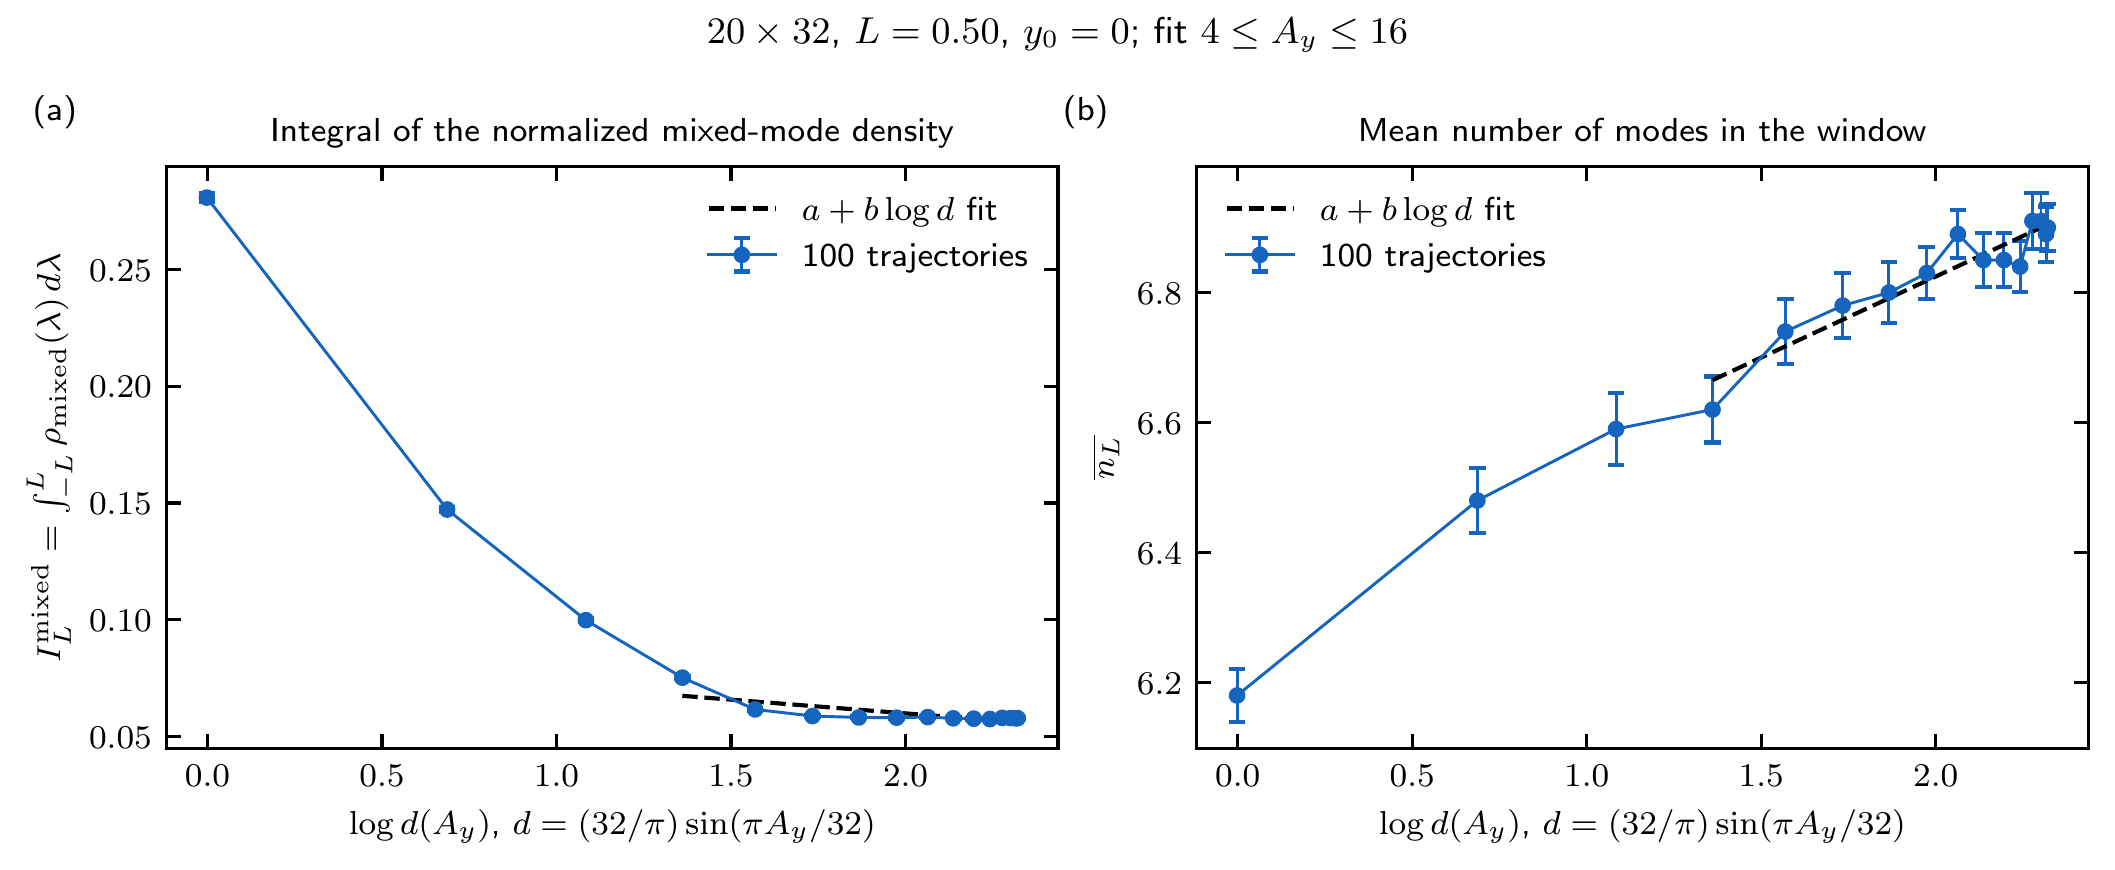

In [5]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
for ax,key,title,ylabel,letter in zip(axes,
 ['mixed_normalized_integral','mode_count'],
 ['Integral of the normalized mixed-mode density','Mean number of modes in the window'],
 [r'$I_L^{\rm mixed}=\int_{-L}^{L}\rho_{\rm mixed}(\lambda)\,d\lambda$',r'$\overline{n_L}$'],['(a)','(b)']):
    ax.errorbar(summary.log_chord,summary[key],yerr=summary[key+'_sem'],color='#1565c0',marker='o',ls='-',lw=.7,ms=3,capsize=2,label='100 trajectories')
    fit=results['fits'][key][str(FIT_MIN_WIDTH)]
    grid=np.linspace(summary.loc[summary.Ay>=FIT_MIN_WIDTH,'log_chord'].min(),summary.log_chord.max(),200)
    ax.plot(grid,fit['intercept']+fit['slope']*grid,color='black',ls='--',lw=1,label=r'$a+b\log d$ fit')
    ax.set(xlabel=r'$\log d(A_y)$, $d=(32/\pi)\sin(\pi A_y/32)$',ylabel=ylabel,title=title)
    ax.text(-.15,1.08,letter,transform=ax.transAxes,fontweight='bold')
    ax.legend(frameon=False,fontsize=8,loc='best')
fig.suptitle(r'$20\times32$, $L=%.2f$, $y_0=0$; fit $%d\leq A_y\leq16$'%(L,FIT_MIN_WIDTH),fontsize=9)
export(fig,'spectral_window_vs_log_chord')

## Subsystem-width dependence
The left panel uses the exact normalization of the earlier mixed-mode plot. The right panel retains all modes in the density normalization, including those near the pure-state endpoints. Both use the same numerator.

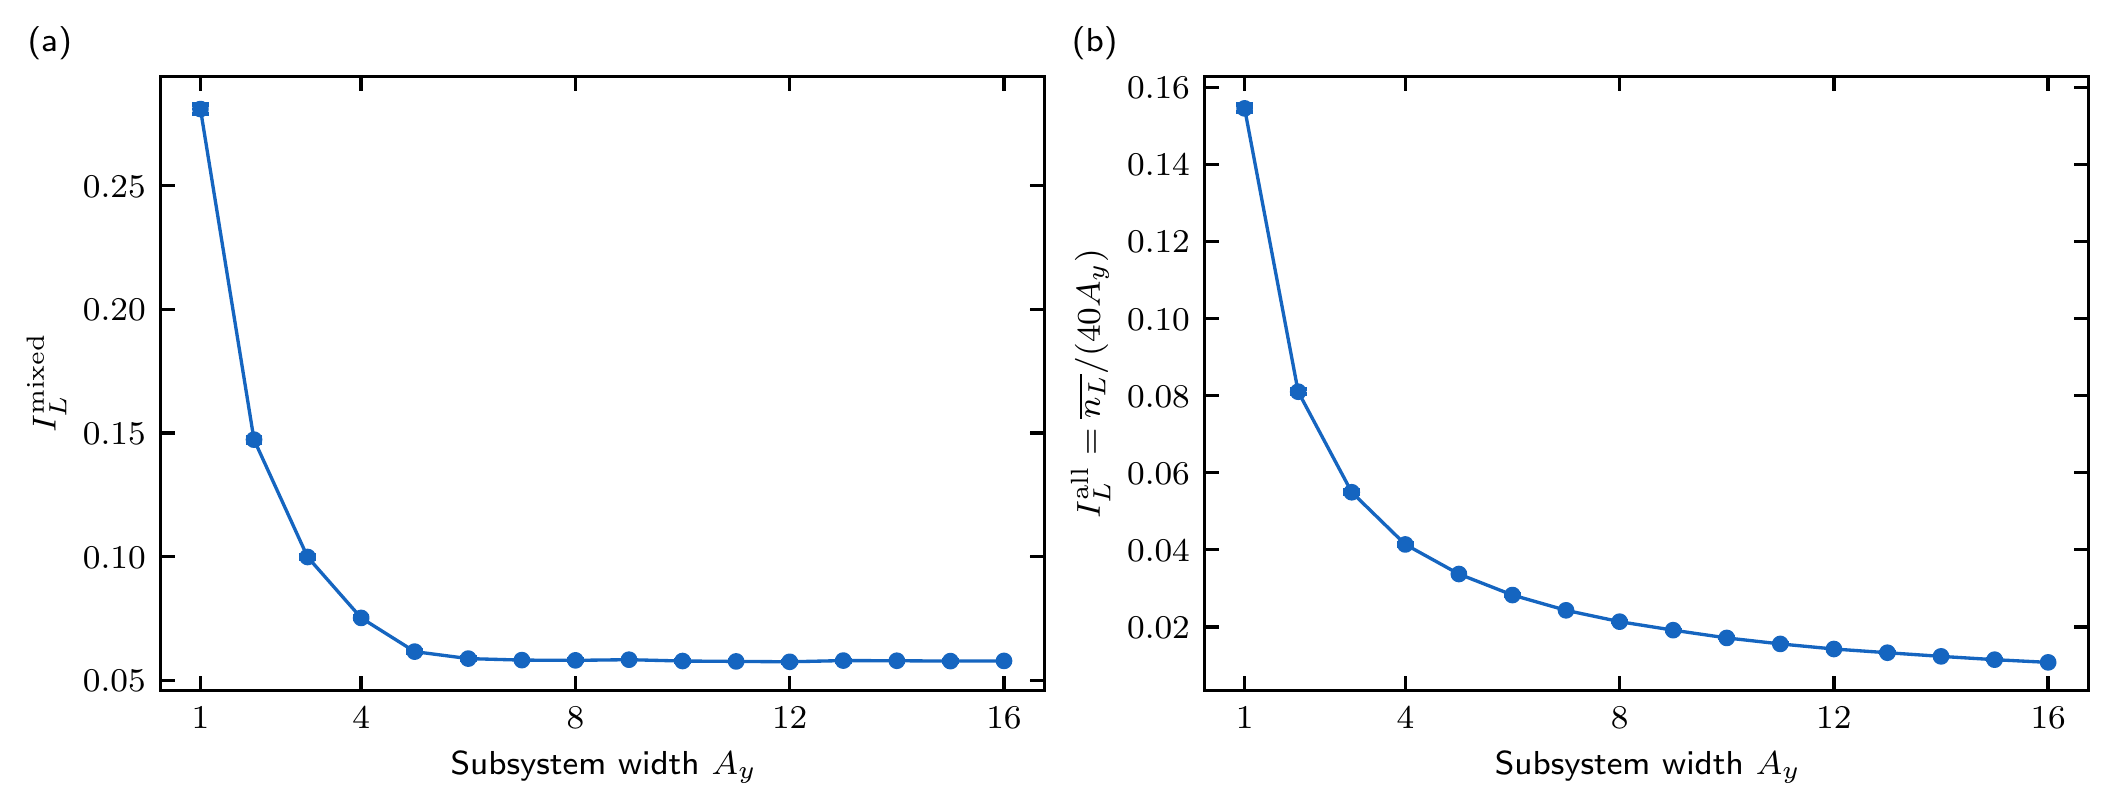

In [6]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.7))
for ax,key,ylabel,letter in zip(axes,['mixed_normalized_integral','all_modes_integral'],
 [r'$I_L^{\rm mixed}$',r'$I_L^{\rm all}=\overline{n_L}/(40A_y)$'],['(a)','(b)']):
    ax.errorbar(summary.Ay,summary[key],yerr=summary[key+'_sem'],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
    ax.set(xlabel=r'Subsystem width $A_y$',ylabel=ylabel,xticks=[1,4,8,12,16])
    ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
export(fig,'spectral_window_vs_width')

Caption: 100 independent trajectories, initialized as pure states with a prepared exterior product frame; hard-wall production protocol at cycle 64. The full system is 20 by 32. Each subsystem starts at y=0, includes every x and both orbitals, and has width 1 through 16. Spectra are computed per trajectory; counts are then pooled to normalize the mixed-mode density. Error bars are trajectory SEM (delta method for pooled ratios). Dashed fits use widths 4–16 by default and propagate correlations between widths. A narrow sharp spectral window can produce level-crossing features, so a straight-line fit alone does not establish an asymptotic scaling law.

## Numerical diagnostics
Raw spectra are preserved. Hermiticity is checked before numerical symmetrization. The half-system spectrum is compared with the previously saved cache. Statistical and fit outputs are saved separately so the window can be edited.

In [7]:
print(json.dumps({k:v for k,v in spectral_diagnostics.items() if k not in ('inputs','identity')},indent=2))
print(json.dumps(results,indent=2))
print('Completed: spectra NPZ, per-sample counts CSV, integrals CSV, covariance NPZ, diagnostics JSON, and two PDF/PNG figures.')

{
  "max_hermiticity_error": 0.0,
  "max_trace_error": 1.2967404927621828e-13,
  "max_frame_orthonormality_error": 1.102891900300992e-14,
  "raw_min": -1.0000000000000098,
  "raw_max": 1.0000000000000306,
  "sample0_alternate_eigenvalue_error": 1.6764367671839864e-14,
  "half_system_previous_cache_max_error": 1.3100631690576847e-14,
  "previous_cache": {
    "path": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/half_system_centered_spectrum_n20_sizes_hard_alpha1_v1/centered_spectra_Ny032.npz",
    "sha256": "7af6e29738dca51b2dd93c64ea9473b38c9efad0ea1a996ac30f2c917e784fdf"
  },
  "cache_sha256": "82d238f25573f1e1f3abd362344ca3c3b8632c924100575c4463422923b78877"
}
{
  "L": 0.5,
  "mixed_tolerance": 1e-08,
  "default_fit_min_width": 4,
  "fit_model": "intercept + slope * log[(32/pi) sin(pi Ay/32)]",
  "estimator": "ratio of pooled counts for normalized density; average count per ind